In [1]:
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from loader import load_dataset
from features import build_features

In [2]:
df, FEATURES = build_features(load_dataset("1d"))

# arch je numerički nestabilan na sirovim log prinosima (r^2 ~ 1e-4),
# pa se skalira na procente
r = df["log_return"].values * 100

am = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
res = am.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3900.50
Distribution:                  Normal   AIC:                           7809.00
Method:            Maximum Likelihood   BIC:                           7830.65
                                        No. Observations:                 1656
Date:                Thu, Sep 10 2026   Df Residuals:                     1655
Time:                        23:08:17   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0993  5.705e-02      1.740  8.188e-02 [-1.25

In [ ]:
p = res.params
mu, omega = p["mu"], p["omega"]
alpha, beta = p["alpha[1]"], p["beta[1]"]

pers = alpha + beta
V = omega / (1 - pers)

print(f"alpha + beta   {pers:.4f}")
print(f"poluvreme      {np.log(0.5)/np.log(pers):.1f} dana")
print(f"V              {V:.3f}  ->  dugorocna dnevna vol {np.sqrt(V):.3f}%")
print(f"uzoracka std   {r.std(ddof=1):.3f}%")
print(f"mu             {mu:.4f}%  (t = {res.tvalues['mu']:.2f})")

alpha + beta 0.8629
poluvreme 4.7 dana
V 7.601  ->  dugorocna dnevna vol 2.757%
uzoracka std 2.673%
mu 0.0993%  (t = 1.74)


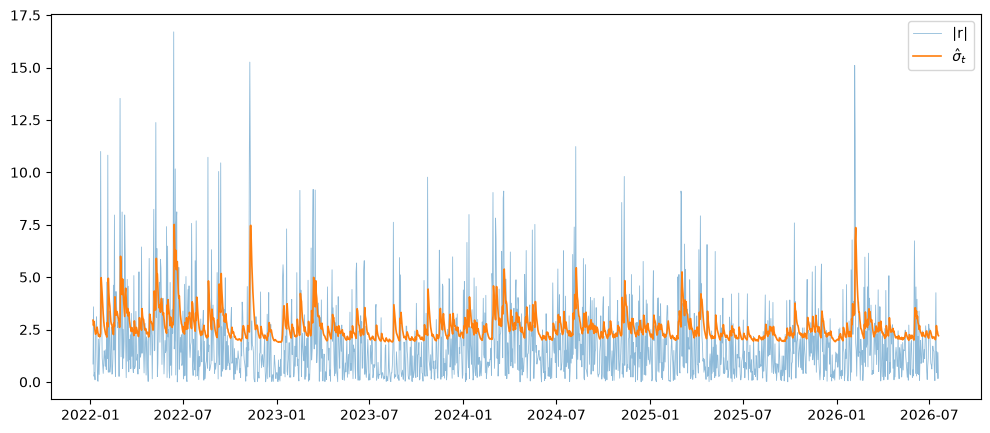

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], np.abs(r), lw=0.6, alpha=0.5, label="|r|")
plt.plot(df["date"], res.conditional_volatility, lw=1.2, label=r"$\hat\sigma_t$")
plt.legend()

In [5]:
res_t = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
print(res_t.summary())

for name, res_ in [("normal", res), ("t", res_t)]:
    p_ = res_.params
    pers_ = p_["alpha[1]"] + p_["beta[1]"]
    print(f"{name:8} a={p_['alpha[1]']:.3f}  b={p_['beta[1]']:.3f}  "
          f"a+b={pers_:.4f}  hl={np.log(0.5)/np.log(pers_):5.1f}  "
          f"LL={res_.loglikelihood:.1f}  BIC={res_.bic:.1f}")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3776.16
Distribution:      Standardized Student's t   AIC:                           7562.32
Method:                  Maximum Likelihood   BIC:                           7589.39
                                              No. Observations:                 1656
Date:                      Thu, Sep 10 2026   Df Residuals:                     1655
Time:                              23:10:32   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     